***Objective:*** To predict the sales of each product at a particular BigMart outlet using historical item and store data, so that the management can make informed decisions around inventory planning, pricing strategy, and outlet operations.

In [484]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats import weightstats
from scipy.stats import chi2_contingency, chi2

import statsmodels.api as sm
import statsmodels.stats.api as sms
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LinearRegression, SGDRegressor,Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler,MinMaxScaler, OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



## Data information

In [485]:
#load the dataset

df=pd.read_csv('bigmart.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [486]:
#About dataset

print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB
None
(8523, 12)


In [487]:
#Checking null values and % of null values

pd.DataFrame({'Null_count':df.isnull().sum(),'Null_percentage':df.isnull().sum()/len(df)*100},dtype=int)

,Null_count,Null_percentage
Item_Identifier,0,0
Item_Weight,1463,17
Item_Fat_Content,0,0
Item_Visibility,0,0
Item_Type,0,0
Item_MRP,0,0
Outlet_Identifier,0,0
Outlet_Establishment_Year,0,0
Outlet_Size,2410,28
Outlet_Location_Type,0,0


## Data Cleaning

In [488]:
#Drop redundant columns
df=df.drop('Item_Identifier',axis=1)

In [489]:
#categorical and numerical columns

df['Outlet_Establishment_Year']=df['Outlet_Establishment_Year'].astype(int)

num=df.select_dtypes(include=np.number).columns.to_list()
cat=df.select_dtypes(include=object).columns.to_list()

In [490]:
#Check the count for each categorical column

for i in cat:
    print(df[i].value_counts())
    print('--'*40)

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
--------------------------------------------------------------------------------
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
--------------------------------------------------------------------------------
Outlet_Identifier
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64
---------------

In [491]:
#Let's standardize with inconsistent Data format for Item_Fat_Content column

df['Item_Fat_Content']=df['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [492]:
df.Outlet_Identifier.unique()

array(['OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027', 'OUT045',
       'OUT017', 'OUT046', 'OUT035', 'OUT019'], dtype=object)

In [493]:
df.Outlet_Size.unique()

array(['Medium', nan, 'High', 'Small'], dtype=object)

In [494]:
#Data cleaning

df[df['Outlet_Size'].isnull()]

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
8,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350
25,13.000,Low Fat,0.099887,Household,45.9060,OUT017,2007,NaN,Tier 2,Supermarket Type1,838.9080
28,5.925,Regular,0.161467,Dairy,45.5086,OUT010,1998,NaN,Tier 3,Grocery Store,178.4344
...,...,...,...,...,...,...,...,...,...,...,...
8502,8.420,Low Fat,0.070712,Household,216.4192,OUT045,2002,NaN,Tier 2,Supermarket Type1,3020.0688
8508,11.350,Regular,0.043246,Fruits and Vegetables,199.4742,OUT045,2002,NaN,Tier 2,Supermarket Type1,2587.9646
8509,8.100,Low Fat,0.214306,Fruits and Vegetables,213.9902,OUT010,1998,NaN,Tier 3,Grocery Store,424.7804
8514,15.000,Regular,0.054489,Canned,57.5904,OUT045,2002,NaN,Tier 2,Supermarket Type1,468.7232


In [495]:
#Checking the relationship between Outlet_Identifier and Outlet_Size to treat null values
df.groupby('Outlet_Identifier')['Outlet_Size'].value_counts()

Outlet_Identifier  Outlet_Size
OUT013             High           932
OUT018             Medium         928
OUT019             Small          528
OUT027             Medium         935
OUT035             Small          930
OUT046             Small          930
OUT049             Medium         930
Name: count, dtype: int64

In [496]:
outletsize_mapping=df.dropna(subset='Outlet_Size').drop_duplicates('Outlet_Identifier').set_index('Outlet_Identifier')['Outlet_Size']
outletsize_mapping

Outlet_Identifier
OUT049    Medium
OUT018    Medium
OUT013      High
OUT027    Medium
OUT046     Small
OUT035     Small
OUT019     Small
Name: Outlet_Size, dtype: object

In [497]:
#Fill null values using logical imputation

df['Outlet_Size']=df['Outlet_Size'].fillna(df['Outlet_Identifier'].map(outletsize_mapping))

In [498]:
df['Outlet_Size'].isnull().sum()

np.int64(2410)

In [499]:
#remaining outlet identifier which doesn't have the outlet size
df[df['Outlet_Size'].isnull()]['Outlet_Identifier'].unique()

array(['OUT010', 'OUT045', 'OUT017'], dtype=object)

In [500]:
#Remaining fill with mode

df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [501]:
df['Outlet_Size'].isnull().sum()

np.int64(0)

In [502]:
#df['Item_Weight'] has <=20% null values so we can impute mean or median based on the distribution of the data
df['Item_Weight'].skew() #slightly skewed so we can impute the null values using mean

np.float64(0.08242620912212255)

In [503]:
df['Item_Weight']=df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [504]:
df['Item_Weight'].isnull().sum()

np.int64(0)

## EDA (Data Exploration)

### Univariate Analysis

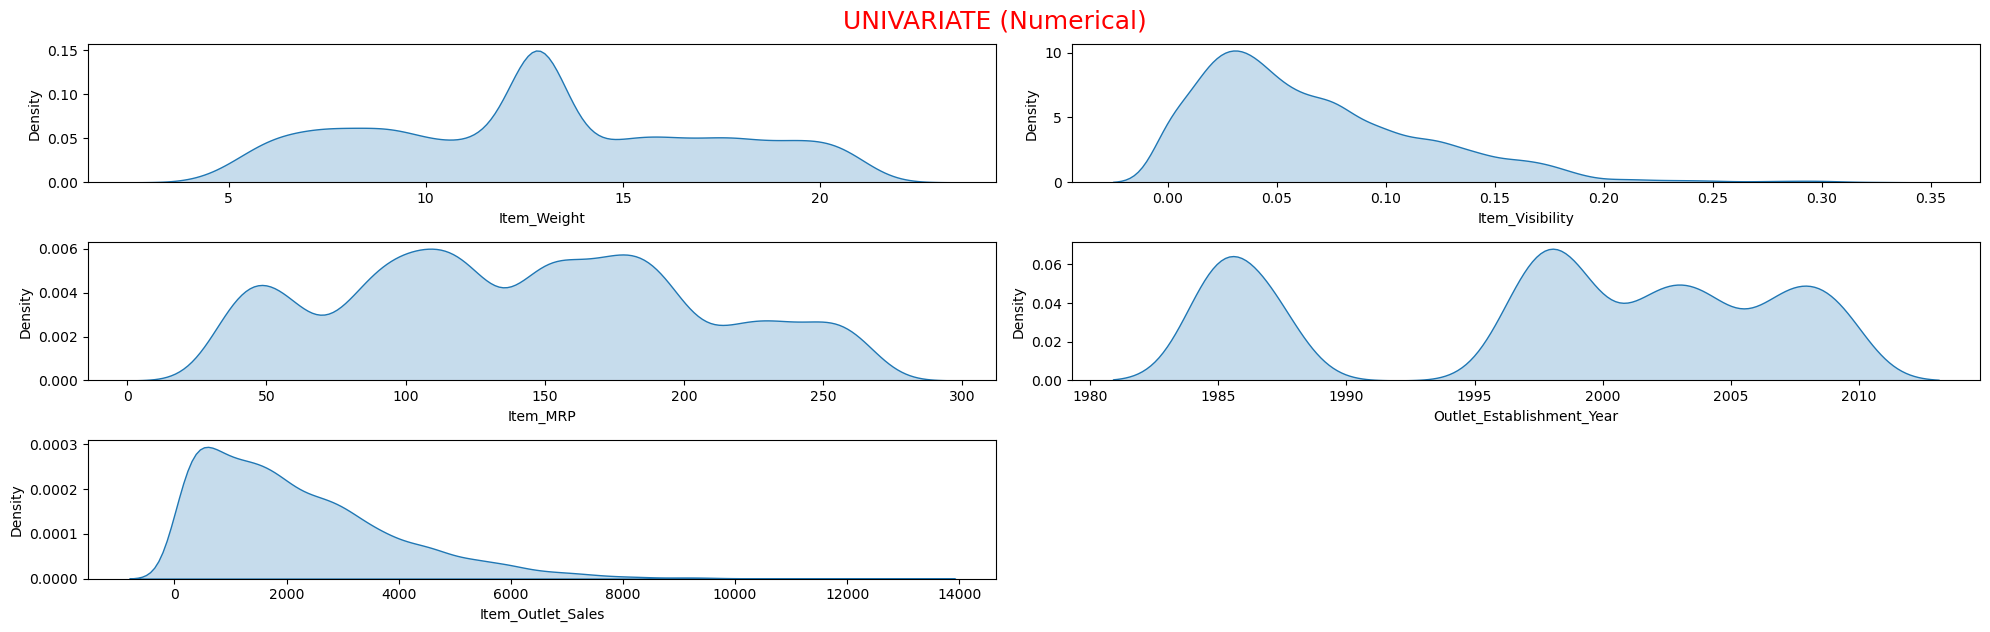

In [505]:
t=1
plt.suptitle('UNIVARIATE (Numerical)',color='red',size=18)
for i in num:
    plt.rcParams['figure.figsize']=[10,10]
    plt.subplot(5,2,t)
    sns.kdeplot(df[i], fill=True)
    t+=1
plt.tight_layout()
plt.show()

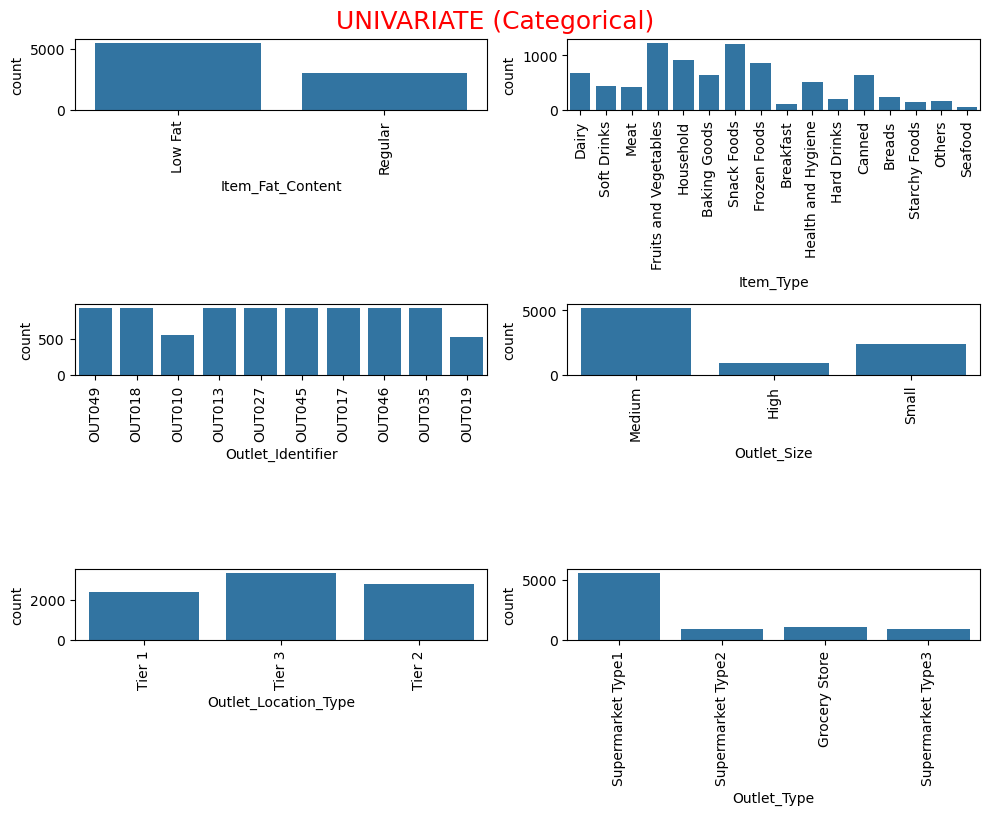

In [506]:
# Explore the Categorical columns

t=1
plt.figure(figsize=(10,12))
plt.suptitle('UNIVARIATE (Categorical)',color='red',size=18)
for i in cat:
    plt.subplot(5,2,t)
    sns.countplot(data=df,x=i)
    plt.xticks(rotation=90)
    t+=1
plt.tight_layout()
plt.show()

## Bivariate Analysis

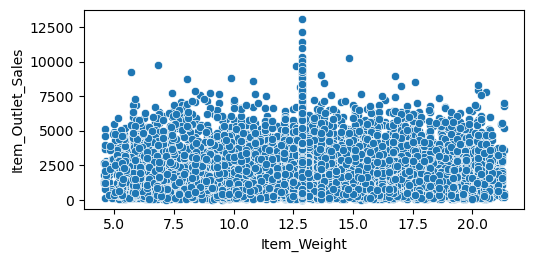

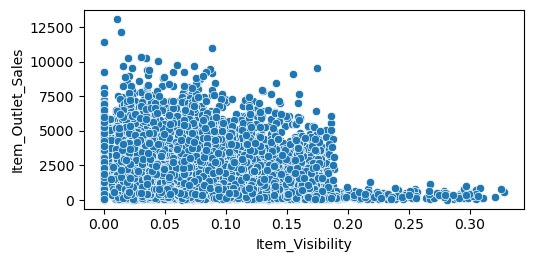

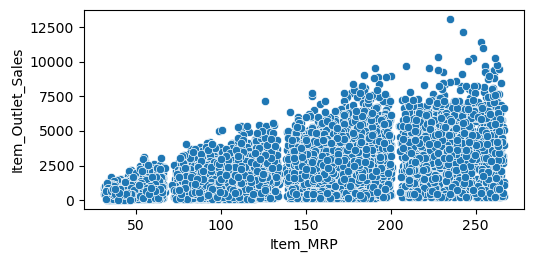

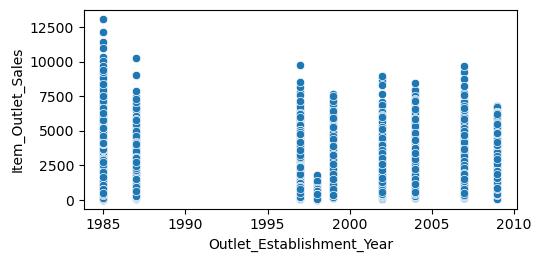

<Figure size 1000x1000 with 0 Axes>

In [507]:
#numeric with Target
t=1
for i in num:
    if i!='Item_Outlet_Sales':
        plt.subplot(4,2,t)
        sns.scatterplot(x=df[i],y=df['Item_Outlet_Sales'])
        t+=1
    plt.tight_layout()
    plt.show()
    

**Inference**

There is no pattern as such between item outlet sales and item weight. However, With increase mrp, the item outlet sales also increases.

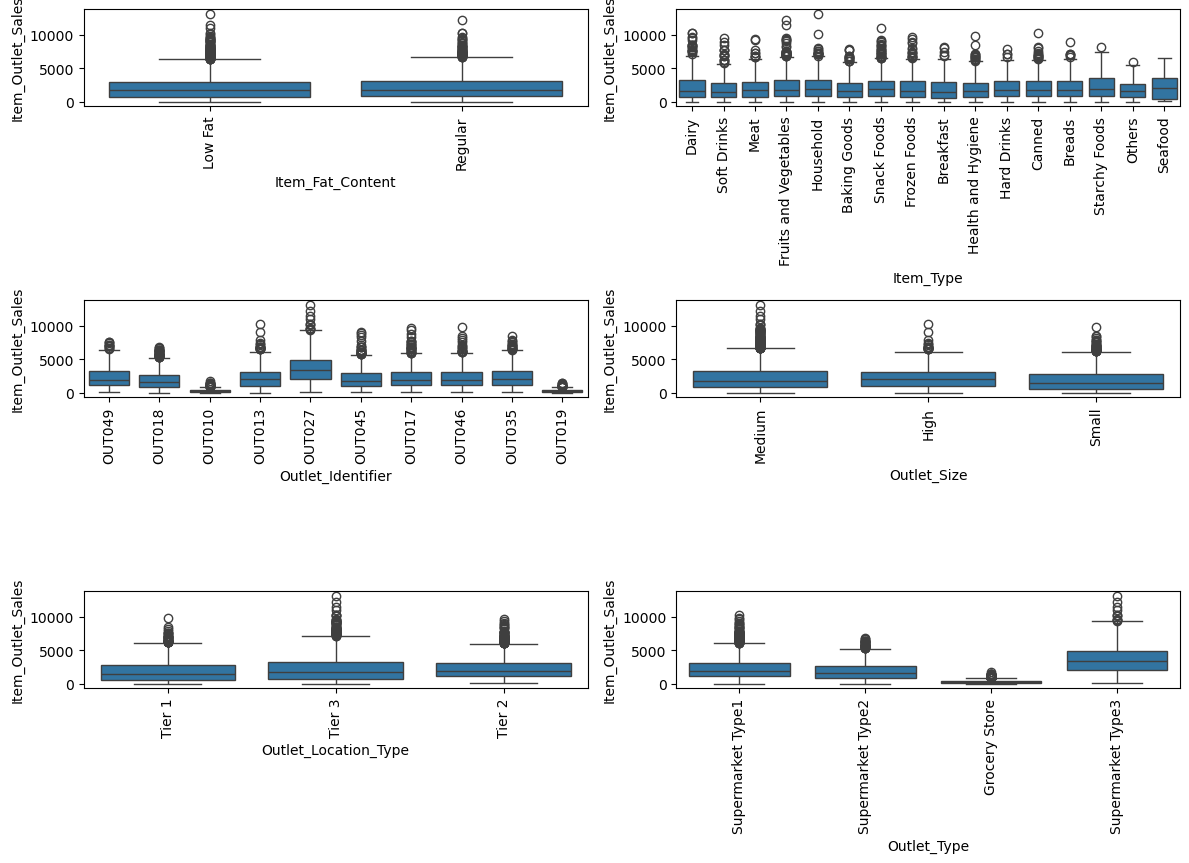

In [508]:
#categorical column with Target column
t = 1

plt.figure(figsize=(12, 10))

for i in cat:
    if i != 'Item_Outlet_Sales':
        plt.subplot(4, 2, t)
        sns.boxplot(x=df[i], y=df['Item_Outlet_Sales'])
        plt.xticks(rotation=90)
        t += 1

plt.tight_layout()
plt.show()

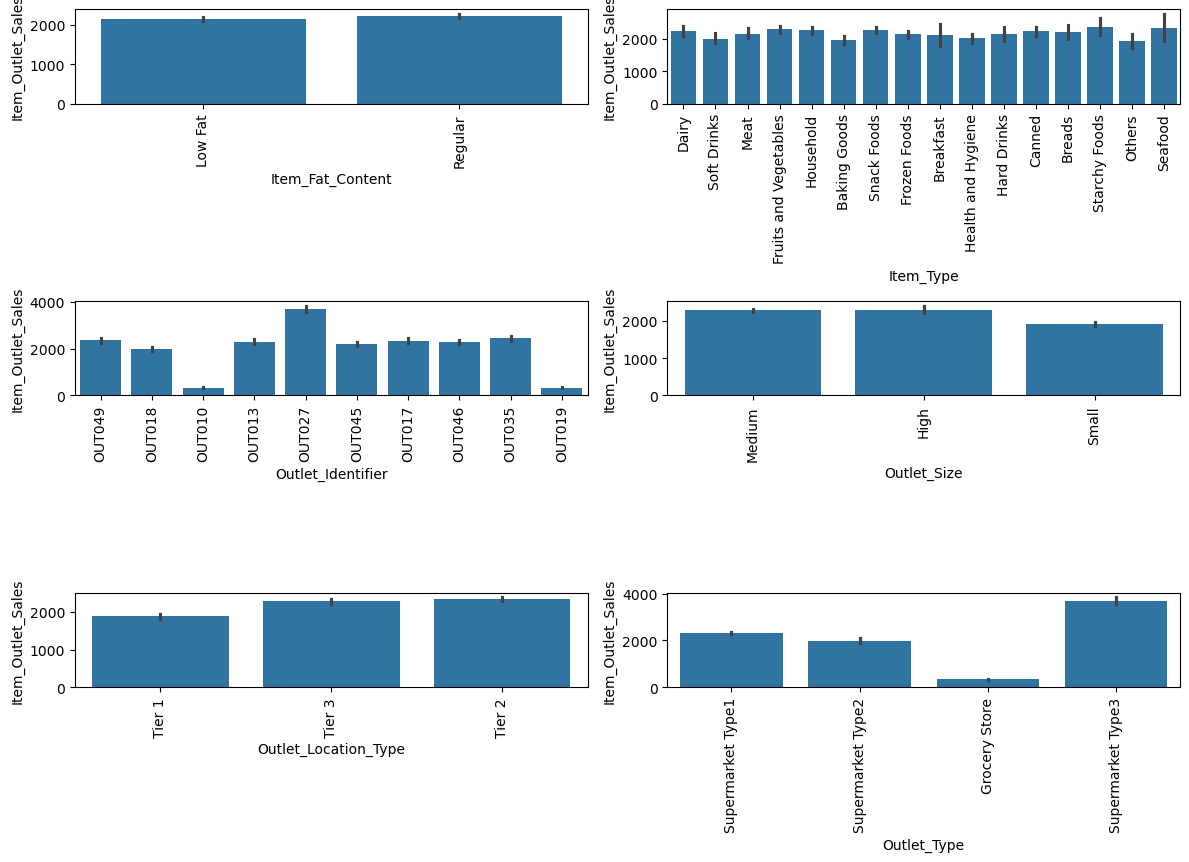

In [509]:
#Cat to numerical with barplot
t = 1

plt.figure(figsize=(12, 10))

for i in cat:
    if i != 'Item_Outlet_Sales':
        plt.subplot(4, 2, t)
        sns.barplot(x=df[i], y=df['Item_Outlet_Sales'])
        plt.xticks(rotation=90)
        t += 1

plt.tight_layout()
plt.show()

### Multivariate Analysis

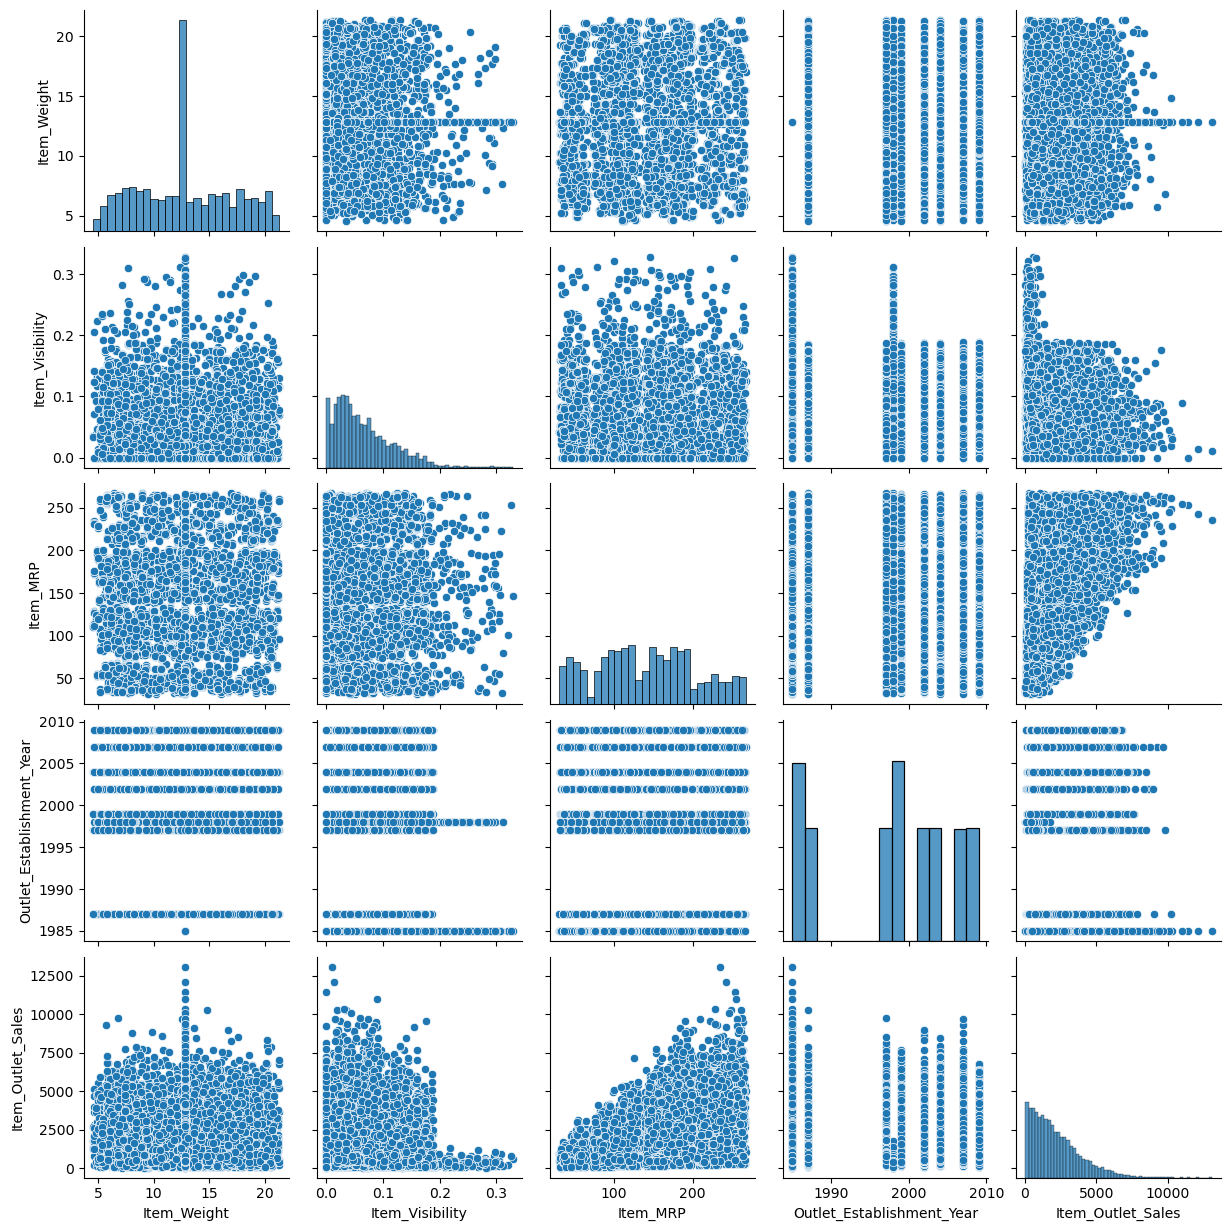

In [406]:
sns.pairplot(df)

## Data Preprocessing

In [407]:
df[num].skew()

Item_Weight                  0.090561
Item_Visibility              1.167091
Item_MRP                     0.127202
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
dtype: float64

In [408]:
#Calculate IQR to identify outliers

q2=df[num].quantile(0.5)
q1=df[num].quantile(0.25)
q3=df[num].quantile(0.75)

iqr=q3-q1

uwl= q3+1.5*iqr
lwl= q1-1.5*iqr

In [409]:
outliers=df[((df[num] < lwl) | (df[num] > uwl)).any(axis=1)]
outliers

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
43,21.350000,Low Fat,0.069103,Canned,259.9278,OUT018,2009,Medium,Tier 3,Supermarket Type2,6768.5228
49,12.857645,Regular,0.255395,Dairy,196.8794,OUT019,1985,Small,Tier 1,Grocery Store,780.3176
83,12.857645,Low Fat,0.293418,Household,194.6136,OUT019,1985,Small,Tier 1,Grocery Store,583.2408
108,12.857645,Low Fat,0.278974,Soft Drinks,225.3720,OUT019,1985,Small,Tier 1,Grocery Store,679.1160
130,12.857645,Low Fat,0.033810,Canned,180.5976,OUT027,1985,Medium,Tier 3,Supermarket Type3,7968.2944
...,...,...,...,...,...,...,...,...,...,...,...
8371,8.270000,Regular,0.214125,Soft Drinks,183.9924,OUT010,1998,Medium,Tier 3,Grocery Store,185.0924
8432,14.000000,Regular,0.227261,Frozen Foods,54.3640,OUT010,1998,Medium,Tier 3,Grocery Store,159.7920
8447,20.350000,Low Fat,0.089975,Dairy,261.6594,OUT017,2007,Medium,Tier 2,Supermarket Type1,7588.1226
8509,8.100000,Low Fat,0.214306,Fruits and Vegetables,213.9902,OUT010,1998,Medium,Tier 3,Grocery Store,424.7804


In [410]:
# percentage of outliers
len(outliers)/len(df)*100

3.8718760999648008

In [411]:
#Drop outliers if it is <5% drop the outliers and reset the index

df=df[~((df[num] < lwl) | (df[num] > uwl)).any(axis=1)]
df

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850
8520,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [412]:
df = df.reset_index(drop=True)

In [413]:
df

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...
8188,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8189,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850
8190,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8191,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [414]:
df[cat]

,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,Regular,Fruits and Vegetables,OUT010,Medium,Tier 3,Grocery Store
4,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...
8188,Low Fat,Snack Foods,OUT013,High,Tier 3,Supermarket Type1
8189,Regular,Baking Goods,OUT045,Medium,Tier 2,Supermarket Type1
8190,Low Fat,Health and Hygiene,OUT035,Small,Tier 2,Supermarket Type1
8191,Regular,Snack Foods,OUT018,Medium,Tier 3,Supermarket Type2


### Feature engineering

In [415]:
a=['Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Location_Type','Outlet_Type']

df=pd.get_dummies(data=df, columns=a,drop_first=True,dtype=int)

In [416]:
df['Outlet_Size'].value_counts()

Outlet_Size
Medium    4991
Small     2285
High       917
Name: count, dtype: int64

In [417]:
df['Outlet_Size']=df['Outlet_Size'].replace({'Small':0,'Medium':1,'High':2})

C:\Users\TECHVITY\AppData\Local\Temp\ipykernel_21808\834618809.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Outlet_Size']=df['Outlet_Size'].replace({'Small':0,'Medium':1,'High':2})


In [418]:
df['Outlet_Age']=2013-df['Outlet_Establishment_Year']
df=df.drop('Outlet_Establishment_Year',axis=1)
num=df.select_dtypes(include=np.number).columns.to_list()

## Model Building and Evaluation

### Baseline model(Linear Regression using OLS)

In [419]:
x=df.drop('Item_Outlet_Sales',axis=1)
x=sm.add_constant(x)
y=df['Item_Outlet_Sales']

In [420]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=100)

In [421]:
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(6554, 36)
(1639, 36)
(6554,)
(1639,)


In [422]:
model_lr=sm.OLS(ytrain,xtrain).fit()

In [423]:
model_lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Item_Outlet_Sales   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     289.6
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:34:03   Log-Likelihood:                -54621.
No. Observations:                6554   AIC:                         1.093e+05
Df Residuals:                    6525   BIC:                         1.095e+05
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                            -906.7105     46.016    -19.704      0.000    -996.916    -816.505
Item_Weight                         0.5361      2.948      0.182      0.856      -5.242       6.314
Item_Visibility                    39.4355    273.713      0.144      0.885    -497.132     576.004
Item_MRP                           14.1806      0.205     69.213      0.000      13.779      14.582
Outlet_Size                        85.9326     15.593      5.511      0.000      55.366     116.500
Item_Fat_Content_Regular           71.4719     28.850      2.477      0.013      14.915     128.028
Item_Type_Breads                   13.4523     84.672      0.159      0.874    -152.533     179.438
Item_Type_Breakfast               -58.8785    124.545     -0.473      0.636    -303.027     185.270
Item_Type_Canned                   -1.4081     64.150     -0.022      0.982    -127.163     124.347
Item_Type_Dairy                  -113.6220     63.802     -1.781      0.075    -238.695      11.451
Item_Type_Frozen Foods            -46.5875     59.668     -0.781      0.435    -163.556      70.381
Item_Type_Fruits and Vegetables    -8.1756     55.973     -0.146      0.884    -117.902     101.551
Item_Type_Hard Drinks              37.9892     90.508      0.420      0.675    -139.436     215.414
Item_Type_Health and Hygiene       -4.5528     69.662     -0.065      0.948    -141.113     132.007
Item_Type_Household               -31.9427     60.628     -0.527      0.598    -150.794      86.908
Item_Type_Meat                    -34.3558     71.922     -0.478      0.633    -175.346     106.634
Item_Type_Others                   76.1420     97.946      0.777      0.437    -115.863     268.147
Item_Type_Seafood                 341.2650    154.125      2.214      0.027      39.130     643.400
Item_Type_Snack Foods             -37.3161     56.247     -0.663      0.507    -147.578      72.946
Item_Type_Soft Drinks             -43.1260     71.247     -0.605      0.545    -182.793      96.541
Item_Type_Starchy Foods            47.9090    105.684      0.453      0.650    -159.266     255.084
Outlet_Identifier_OUT013          791.6838     40.546     19.526      0.000     712.201     871.166
Outlet_Identifier_OUT017           -7.9854     30.137     -0.265      0.791     -67.064      51.093
Outlet_Identifier_OUT018          778.8992     34.456     22.605      0.000     711.353     846.445
Outlet_Identifier_OUT019         -488.5817     24.593    -19.867      0.000    -536.792    -440.371
Outlet_Identifier_OUT027         1554.0444     30.809     50.441      0.000    1493.648    1614.441
Outlet_Identifier_OUT035          144.9961     27.054      5.359      0.000      91.961     198.031
Outlet_Identifier_OUT045          -98.0829     29.965     -3.273      0.001    -156

In [424]:
ypred=model_lr.predict(xtest)

In [425]:
y.max()

6478.234

In [426]:
root_mean_squared_error(ytest,ypred)

1002.1031880051763

### Assumptions check for Linear Regression

* Ypred is numeric
* Absence of multicolinearity
* Ypred and resid should show no pattern so that x and y has linear relationship
* Error terms should be homoscedastic
* There shouldn't be any autocorrelation

#### Multicolinearity

<Axes: >

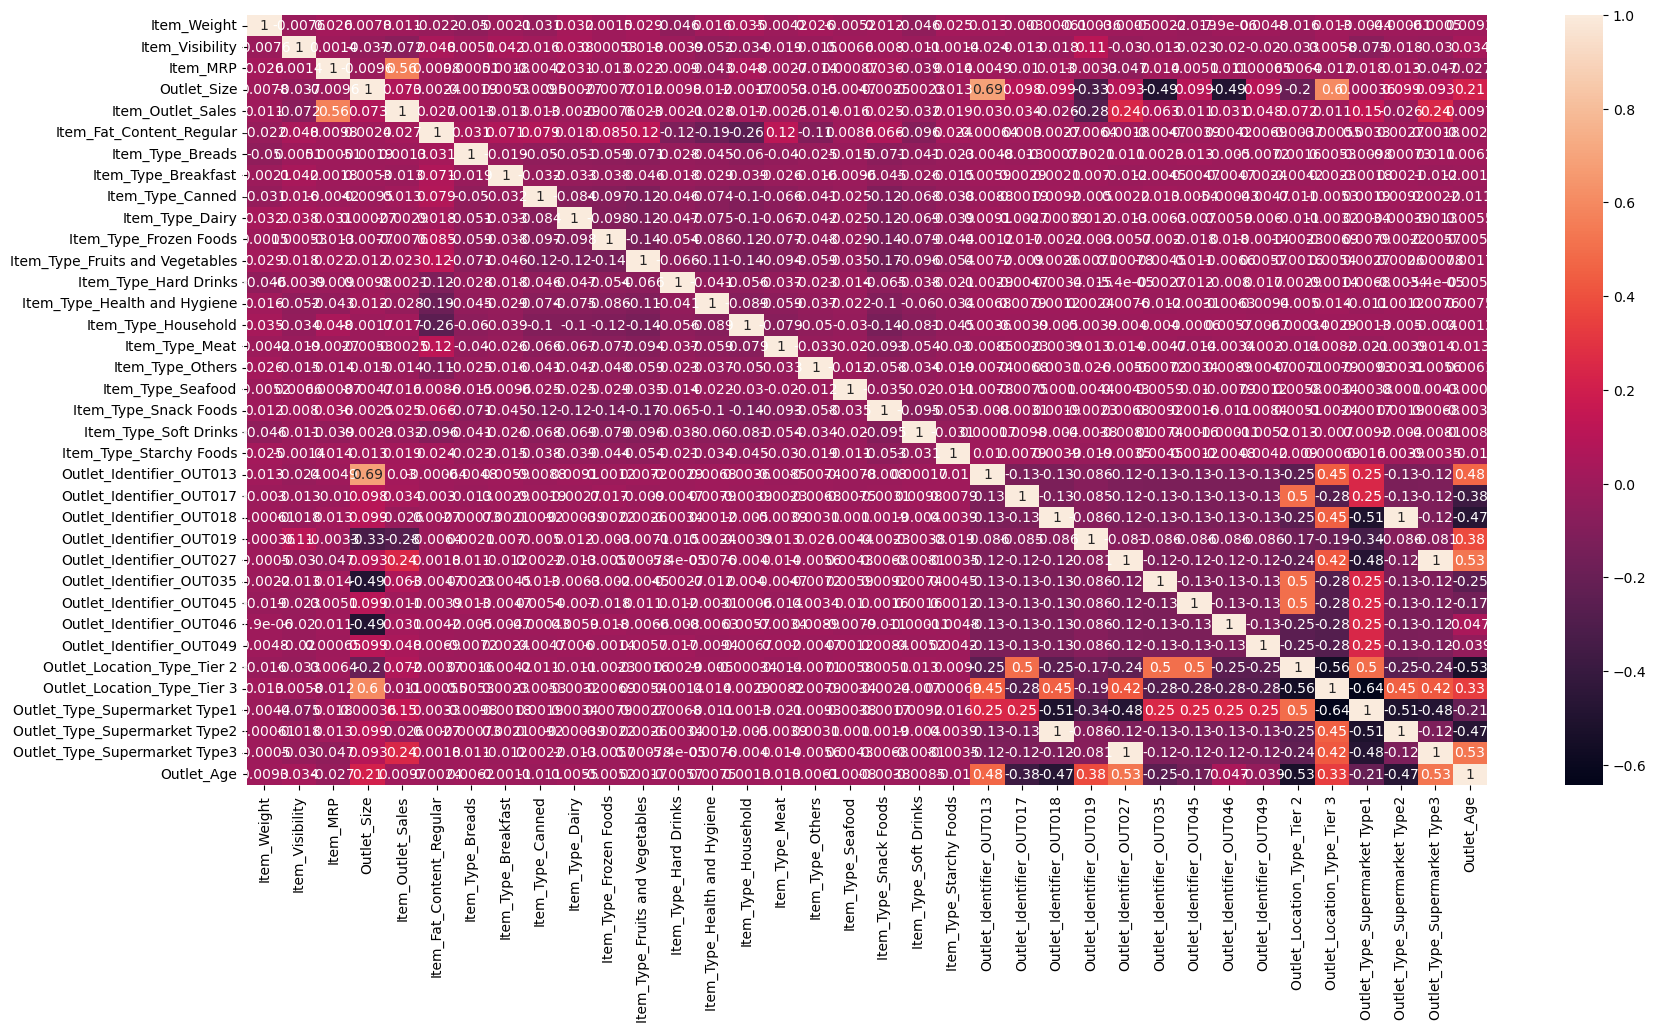

In [427]:
plt.rcParams['figure.figsize']=[20,10]
sns.heatmap(df[num].corr(),annot=True)

In [428]:
#There is high multicolinearity with condition number >1000
#Let's check which variables shows high multicolinearity by using VIF

vif=[VIF(x.values,i) for i in range(x.shape[1])]
vif_df=pd.DataFrame(vif,index=x.columns,columns=['VIF'])
vif_df.sort_values(by='VIF',ascending=False)       

C:\Users\TECHVITY\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\TECHVITY\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
Outlet_Age,inf
Outlet_Identifier_OUT013,inf
Outlet_Identifier_OUT018,inf
Outlet_Identifier_OUT019,inf
Outlet_Identifier_OUT027,inf
Outlet_Identifier_OUT035,inf
Outlet_Identifier_OUT045,inf
Outlet_Identifier_OUT046,inf
Outlet_Identifier_OUT049,inf
Outlet_Location_Type_Tier 2,inf


In [429]:
# autocorrelation check 
# Durbin Watson ~2, there is no autocorrelation

In [430]:
ypredmodel=model_lr.predict(x)

<Axes: xlabel='None', ylabel='None'>

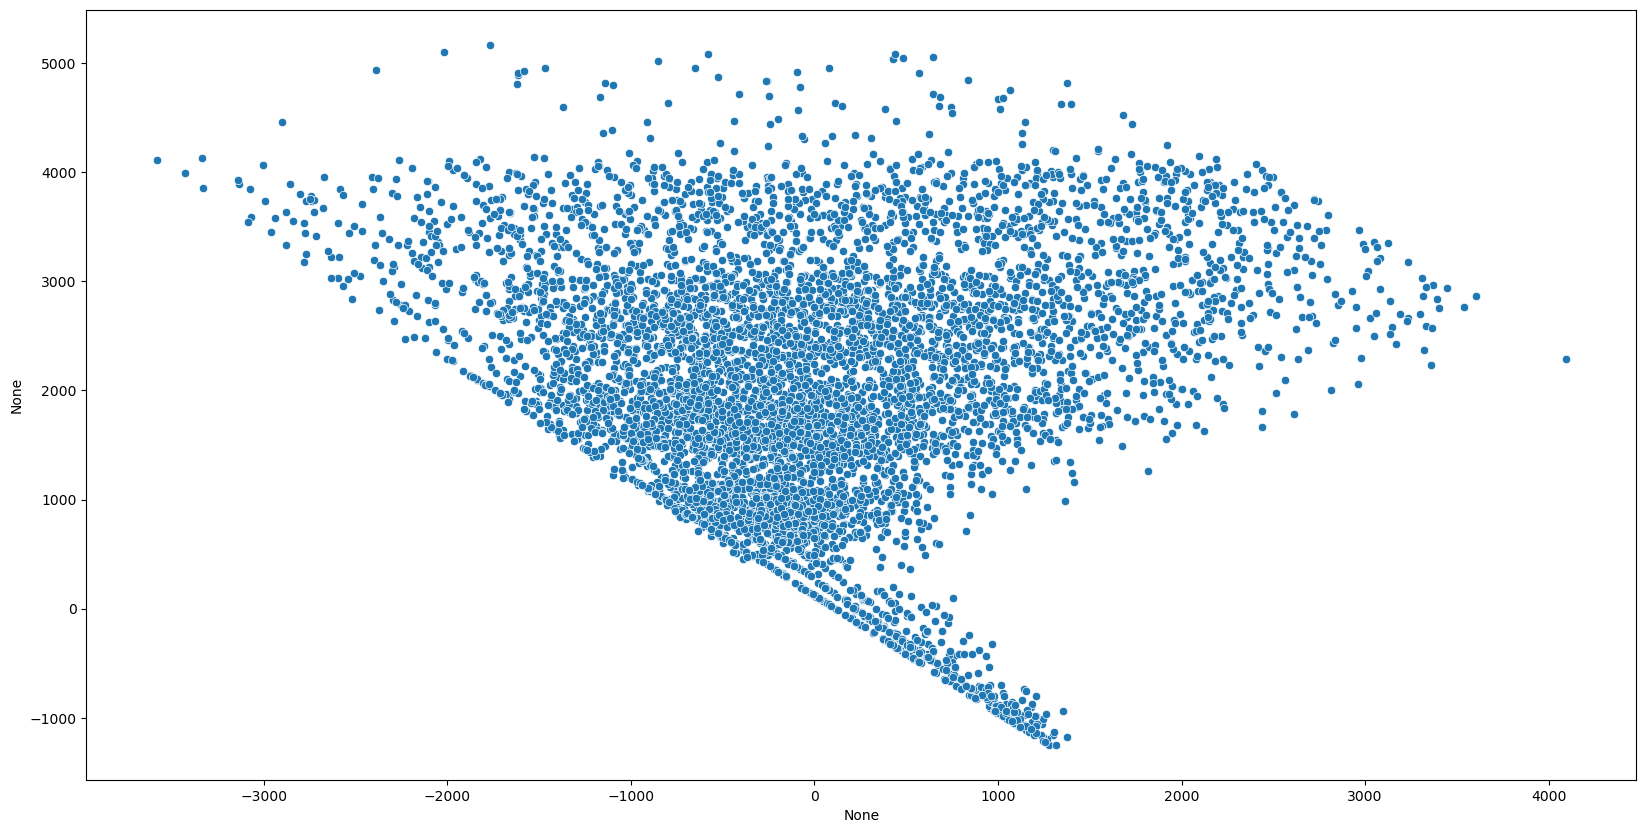

In [431]:
#There is no pattern between error and ypred
sns.scatterplot(data=df,x=model_lr.resid,y=ypredmodel)

In [432]:
model=sm.OLS(y,x).fit()

In [433]:
# H0: The errors terms are homoscadastic
# H1: The errors terms are heteroscadastic

sms.het_goldfeldquandt(model.resid,x)

(np.float64(0.9605961083954092), np.float64(0.9000492202725279), 'increasing')

In [434]:
#p val>0.05, we fail to reject h0, error terms are homoscedastic

In [435]:
#Normality check

# H0: Data is Normal
# H1: Data is NOT Normal

stats.shapiro(model.resid)

C:\Users\TECHVITY\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8193.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9886261691618269), pvalue=np.float64(4.0475468600006194e-25))

In [436]:
# As p_value is less than 0.05, We reject H0.
# Hence,  Data is NOT Normal

C:\Users\TECHVITY\AppData\Local\Temp\ipykernel_21808\1265494514.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Item_Outlet_Sales'])


<Axes: xlabel='Item_Outlet_Sales', ylabel='Density'>

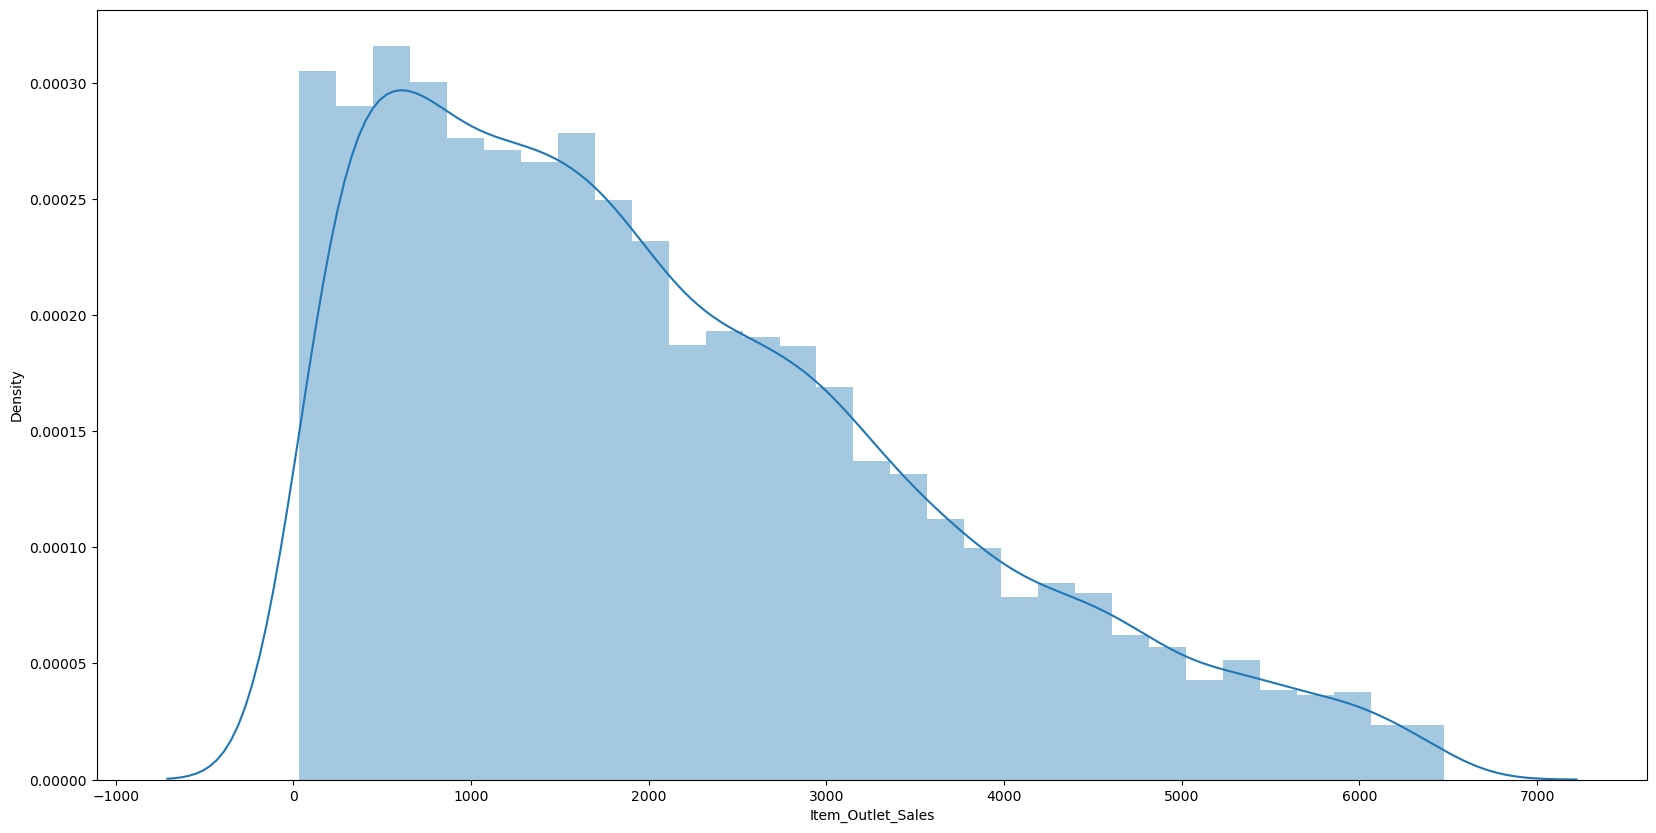

In [437]:
sns.distplot(df['Item_Outlet_Sales'])

## Transformation

***Box-Cox***

In [438]:
from scipy import stats

In [439]:
box_y, lam=stats.boxcox(y)

In [440]:
model_box=sm.OLS(box_y,x).fit()

In [441]:
model_box.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     540.0
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:34:09   Log-Likelihood:                -30844.
No. Observations:                8193   AIC:                         6.175e+04
Df Residuals:                    8164   BIC:                         6.195e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               0.2305      0.429      0.537      0.591      -0.610       1.071
Item_Weight                        -0.0066      0.027     -0.243      0.808      -0.060       0.047
Item_Visibility                    -1.8588      2.540     -0.732      0.464      -6.839       3.121
Item_MRP                            0.1604      0.002     84.741      0.000       0.157       0.164
Outlet_Size                         2.6098      0.144     18.122      0.000       2.328       2.892
Item_Fat_Content_Regular            0.5129      0.267      1.919      0.055      -0.011       1.037
Item_Type_Breads                    0.3302      0.794      0.416      0.677      -1.225       1.886
Item_Type_Breakfast                -1.5258      1.124     -1.357      0.175      -3.730       0.678
Item_Type_Canned                    0.5151      0.593      0.869      0.385      -0.647       1.677
Item_Type_Dairy                    -1.2064      0.590     -2.046      0.041      -2.362      -0.051
Item_Type_Frozen Foods             -0.6025      0.555     -1.085      0.278      -1.691       0.486
Item_Type_Fruits and Vegetables     0.0360      0.520      0.069      0.945      -0.984       1.056
Item_Type_Hard Drinks               0.0971      0.850      0.114      0.909      -1.570       1.764
Item_Type_Health and Hygiene        0.2593      0.640      0.405      0.685      -0.996       1.514
Item_Type_Household                -0.2587      0.566     -0.457      0.648      -1.368       0.851
Item_Type_Meat                      0.2937      0.668      0.440      0.660      -1.015       1.602
Item_Type_Others                    0.4963      0.922      0.538      0.590      -1.311       2.304
Item_Type_Seafood                   1.6739      1.415      1.183      0.237      -1.099       4.447
Item_Type_Snack Foods               0.0309      0.522      0.059      0.953      -0.993       1.055
Item_Type_Soft Drinks              -0.5954      0.663     -0.898      0.369      -1.895       0.704
Item_Type_Starchy Foods            -0.4739      0.983     -0.482      0.630      -2.401       1.453
Outlet_Identifier_OUT013            4.5479      0.377     12.067      0.000       3.809       5.287
Outlet_Identifier_OUT017            1.7392      0.279      6.229      0.000       1.192       2.287
Outlet_Identifier_OUT018           14.8282      0.321     46.254      0.000      14.200      15.457
Outlet_Identifier_OUT019           -7.5473      0.230    -32.868      0.000      -7.997      -7.097
Outlet_Identifier_OUT027           18.6777      0.288     64.928      0.000      18.114      19.242
Outlet_Identifier_OUT035            4.1269      0.250     16.485      0.000       3.636       4.618
Outlet_Identifier_OUT045           -1.1337      0.276     -4.102      0.000      -1

***Squareroot Transformation***

In [442]:
sqrt_y=np.sqrt(y)

In [443]:
model_sqrt=sm.OLS(sqrt_y,x).fit()

In [444]:
model_sqrt.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Item_Outlet_Sales   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     506.6
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:34:09   Log-Likelihood:                -30767.
No. Observations:                8193   AIC:                         6.159e+04
Df Residuals:                    8164   BIC:                         6.180e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -2.3907      0.425     -5.627      0.000      -3.224      -1.558
Item_Weight                        -0.0056      0.027     -0.207      0.836      -0.059       0.047
Item_Visibility                    -1.7957      2.517     -0.714      0.476      -6.729       3.137
Item_MRP                            0.1574      0.002     83.945      0.000       0.154       0.161
Outlet_Size                         2.1985      0.143     15.410      0.000       1.919       2.478
Item_Fat_Content_Regular            0.5211      0.265      1.968      0.049       0.002       1.040
Item_Type_Breads                    0.2627      0.786      0.334      0.738      -1.278       1.804
Item_Type_Breakfast                -1.4519      1.114     -1.304      0.192      -3.635       0.731
Item_Type_Canned                    0.4872      0.587      0.830      0.407      -0.664       1.638
Item_Type_Dairy                    -1.1496      0.584     -1.968      0.049      -2.295      -0.005
Item_Type_Frozen Foods             -0.5268      0.550     -0.957      0.338      -1.605       0.552
Item_Type_Fruits and Vegetables     0.0508      0.515      0.099      0.921      -0.959       1.061
Item_Type_Hard Drinks               0.1198      0.842      0.142      0.887      -1.531       1.771
Item_Type_Health and Hygiene        0.2183      0.634      0.344      0.731      -1.025       1.462
Item_Type_Household                -0.2389      0.561     -0.426      0.670      -1.338       0.860
Item_Type_Meat                      0.2405      0.661      0.364      0.716      -1.056       1.537
Item_Type_Others                    0.4788      0.913      0.524      0.600      -1.312       2.269
Item_Type_Seafood                   1.8240      1.401      1.301      0.193      -0.923       4.571
Item_Type_Snack Foods               0.0076      0.517      0.015      0.988      -1.006       1.022
Item_Type_Soft Drinks              -0.5999      0.657     -0.913      0.361      -1.888       0.688
Item_Type_Starchy Foods            -0.3575      0.974     -0.367      0.714      -2.267       1.552
Outlet_Identifier_OUT013            5.7037      0.373     15.278      0.000       4.972       6.436
Outlet_Identifier_OUT017            1.2491      0.277      4.516      0.000       0.707       1.791
Outlet_Identifier_OUT018           13.2900      0.318     41.849      0.000      12.667      13.913
Outlet_Identifier_OUT019           -6.9965      0.227    -30.758      0.000      -7.442      -6.551
Outlet_Identifier_OUT027           18.2669      0.285     64.102      0.000      17.708      18.825
Outlet_Identifier_OUT035            3.5246      0.248     14.213      0.000       3.039       4.011
Outlet_Identifier_OUT045           -1.1240      0.274     -4.105      0.000      -1

In [445]:
x=x.drop('const', axis=1)

In [446]:
x.columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Size',
       'Item_Fat_Content_Regular', 'Item_Type_Breads', 'Item_Type_Breakfast',
       'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat',
       'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods',
       'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods',
       'Outlet_Identifier_OUT013', 'Outlet_Identifier_OUT017',
       'Outlet_Identifier_OUT018', 'Outlet_Identifier_OUT019',
       'Outlet_Identifier_OUT027', 'Outlet_Identifier_OUT035',
       'Outlet_Identifier_OUT045', 'Outlet_Identifier_OUT046',
       'Outlet_Identifier_OUT049', 'Outlet_Location_Type_Tier 2',
       'Outlet_Location_Type_Tier 3', 'Outlet_Type_Supermarket Type1',
       'Outlet_Type_Supermarket Type2', 'Outlet_Type_Supermarket Type3',
       'Outlet_Age'],
      dtype='object

In [447]:
#There is high multicolinearity with condition number >1000
#Let's check which variables shows high multicolinearity by using VIF

vif=[VIF(x.values,i) for i in range(x.shape[1])]
vif_df=pd.DataFrame(vif,index=x.columns,columns=['VIF'])
vif_df.sort_values(by='VIF',ascending=False)       

C:\Users\TECHVITY\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
Outlet_Age,inf
Outlet_Identifier_OUT013,inf
Outlet_Identifier_OUT018,inf
Outlet_Identifier_OUT019,inf
Outlet_Identifier_OUT027,inf
Outlet_Identifier_OUT035,inf
Outlet_Identifier_OUT045,inf
Outlet_Identifier_OUT046,inf
Outlet_Identifier_OUT049,inf
Outlet_Location_Type_Tier 2,inf


In [448]:
#Since outlet size, outlet type, outlet age were giving the same information so we dropped all of them to reduce the multicolinearity

x=x.drop(['Outlet_Location_Type_Tier 2','Outlet_Location_Type_Tier 3','Outlet_Type_Supermarket Type1','Outlet_Type_Supermarket Type2','Outlet_Size','Outlet_Type_Supermarket Type3','Outlet_Age'], axis=1)

In [449]:
#After dropping all the columns that were giving same information, let's check the VIF

vif=[VIF(x.values,i) for i in range(x.shape[1])]
vif_df=pd.DataFrame(vif,index=x.columns,columns=['VIF'])
vif_df.sort_values(by='VIF',ascending=False)       

,VIF
Item_Weight,8.333121
Item_MRP,5.660930
Item_Visibility,2.749325
Item_Type_Fruits and Vegetables,2.457399
Item_Type_Snack Foods,2.418661
Outlet_Identifier_OUT018,2.152390
Item_Type_Household,2.147690
Outlet_Identifier_OUT049,2.144803
Outlet_Identifier_OUT013,2.141541
Outlet_Identifier_OUT035,2.139163


## 1. Linear Regression with Transformed Target(using squareroot transformation technique)

In [450]:
lr=LinearRegression()

In [451]:
x.shape

(8193, 28)

In [452]:
sqrt_y.shape

(8193,)

In [453]:
xtrain,xtest,sqrt_ytrain,sqrt_ytest=train_test_split(x,sqrt_y,test_size=0.2,random_state=100)

In [454]:
print(xtrain.shape)
print(xtest.shape)
print(sqrt_ytrain.shape)
print(sqrt_ytest.shape)

(6554, 28)
(1639, 28)
(6554,)
(1639,)


In [455]:
lr.fit(xtrain,sqrt_ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [456]:
ypredtest=lr.predict(xtest)

In [457]:
root_mean_squared_error(sqrt_ytest,ypredtest)

10.412157911155713

In [458]:
r2_score(sqrt_ytest,ypredtest)

0.6183683619711392

In [459]:
ypredtrain=lr.predict(xtrain)

In [460]:
root_mean_squared_error(sqrt_ytrain,ypredtrain)

10.331654024482049

In [461]:
r2_score(sqrt_ytrain,ypredtrain)

0.6382563219251134

## 2. Ridge model

In [462]:
r=Ridge()

In [463]:
r.fit(xtrain,sqrt_ytrain)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [464]:
ypredtest=r.predict(xtest)

In [465]:
root_mean_squared_error(sqrt_ytest,ypredtest)

10.412109204264702

In [466]:
r2_score(sqrt_ytest,ypredtest)

0.6183719324216226

In [467]:
#No improvement with Ridge because the Linear model was not a overfit so it didn't improve the model performance

## 3. DecisionTree Regressor

In [468]:
dt=DecisionTreeRegressor()

In [469]:
dt.fit(xtrain,sqrt_ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [470]:
ypredtest=dt.predict(xtest)

In [471]:
ypredtrain=dt.predict(xtrain)

In [472]:
root_mean_squared_error(ypredtrain,sqrt_ytrain)

0.0

In [473]:
r2_score(ypredtrain,sqrt_ytrain)

1.0

In [474]:
root_mean_squared_error(ypredtest,sqrt_ytest)

14.715067037064108

In [475]:
r2_score(ypredtest,sqrt_ytest)

0.2627238068593558

## 3. DecisionTree with Hyperparameter tuning

In [476]:
dt = DecisionTreeRegressor(
    max_depth=5,          # limit depth
    min_samples_split=20, # don't split tiny nodes
    min_samples_leaf=10,  # leaf must have enough samples
    random_state=42
)

In [477]:
dt.fit(xtrain,sqrt_ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [478]:
ypredtest=dt.predict(xtest)

In [479]:
ypredtrain=dt.predict(xtrain)

In [480]:
root_mean_squared_error(ypredtrain,sqrt_ytrain)

12.001608520089011

In [481]:
r2_score(ypredtrain,sqrt_ytrain)

0.04635899870379867

## 4. RandomForest Regressor

In [482]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(xtrain, sqrt_ytrain)
print(r2_score(sqrt_ytest, rf.predict(xtest))) 

0.5551092666415227


## 5. GradientBoosting Regressor

In [483]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(xtrain, sqrt_ytrain)
print(r2_score(sqrt_ytest, gb.predict(xtest))) 

0.5589179789094618


***Conclusion:***

Data has smooth linear patterns    → Linear Regression wins

Data has complex non-linearities   → Tree models win

Data has both                      → Gradient Boosting wins

Linear Regression with square root transformation on the target variable emerged as the best model with a **test R² of 0.618**, demonstrating strong generalization with no overfitting, outperforming tree-based ensemble methods due to the predominantly linear nature of the BigMart sales data.

Linear Regression with Square Root Transformation was the best model because:

The dataset has predominantly linear, additive relationships
Item_MRP drives sales linearly — exactly what OLS captures best
Tree-based models couldn't efficiently approximate the smooth linear signal
Train R² (0.638) and Test R² (0.618) are very close → model generalizes well, no overfitting
Square root transformation on target helped meet the normality assumption of linear regression

In [515]:
#Linear model coefficients
coef_df = pd.DataFrame({
    'Coefficient': lr.coef_
}, index=xtrain.columns).sort_values('Coefficient', ascending=False)

print(coef_df)
print(f"\nIntercept: {lr.intercept_}")

                                 Coefficient
Outlet_Identifier_OUT027           39.072001
Outlet_Identifier_OUT035           28.733595
Outlet_Identifier_OUT049           28.653169
Outlet_Identifier_OUT017           28.283281
Outlet_Identifier_OUT046           27.695364
Outlet_Identifier_OUT013           27.590249
Outlet_Identifier_OUT045           26.872828
Outlet_Identifier_OUT018           24.665058
Item_Type_Seafood                   2.684271
Item_Type_Others                    0.911026
Item_Fat_Content_Regular            0.733295
Outlet_Identifier_OUT019            0.690781
Item_Type_Breads                    0.467134
Item_Type_Hard Drinks               0.270437
Item_Type_Health and Hygiene        0.172917
Item_MRP                            0.158216
Item_Visibility                     0.082952
Item_Type_Starchy Foods             0.000360
Item_Weight                        -0.001098
Item_Type_Canned                   -0.008193
Item_Type_Meat                     -0.219881
Item_Type_

1. Outlet identity → strongest predictor of sales
2. Item MRP               → strongest item-level predictor  
3. Item type              → moderate effect
4. Item weight            → practically irrelevant
5. Item visibility        → very weak effect

In [517]:
df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean()

Outlet_Identifier
OUT010     339.351662
OUT013    2298.995256
OUT017    2340.675263
OUT018    1995.498739
OUT019     340.329723
OUT027    3694.038558
OUT035    2438.841866
OUT045    2192.384798
OUT046    2277.844267
OUT049    2348.354635
Name: Item_Outlet_Sales, dtype: float64